# Early Detection of Thoracic Disease Using NIH Chest X-rays
### Final Project Report — PSTAT 134, Spring 2026

---

**Team:** Data Engineer · ML Engineer · Statistician · Research Lead · Visualization

**Dataset:** NIH Clinical Center Chest X-ray Dataset — 112,120 frontal-view X-rays from 30,805 patients

**Task:** Binary classification — *Disease Present* vs *No Finding*

**Infrastructure:** Google Cloud Platform (BigQuery + Cloud Storage), PyTorch, Python 3

---

> This notebook is the final report artifact. It loads saved model outputs and presents the complete project story — from problem framing through clinical interpretation. No model training is needed to run it.

## Setup

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)

MODELS_DIR = Path("../../models")

df_preds       = pd.read_csv(MODELS_DIR / "predictions_resnet50.csv")
best_threshold = float(open(MODELS_DIR / "best_threshold.txt").read().strip())

all_labels = df_preds["true_label"].values
all_probs  = df_preds["prob_disease"].values
all_preds  = (all_probs >= best_threshold).astype(int)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"Loaded {len(all_labels)} test-set predictions. Ready.")

Loaded 1000 test-set predictions. Ready.


---
## 1. The Problem

Chest X-rays are among the most common diagnostic imaging studies performed globally. Interpreting them accurately is time-consuming and requires specialist training — radiologist capacity is limited, and diagnostic backlogs in high-volume settings lead to delayed care.

This project asks: **can a machine learning model learn to distinguish disease-present X-rays from normal ones using only image data and noisy clinical labels?**

The NIH Chest X-ray dataset provides 112,120 frontal-view X-rays from 30,805 unique patients. Labels are extracted from radiology report text via NLP — they are approximate, not gold-standard, with an estimated label accuracy around 90%. This is a realistic constraint: in practice, clean expert annotations at this scale do not exist.

We frame the task as binary classification:
- **Positive (Disease Present):** any image labeled with one or more pathologies
- **Negative (No Finding):** images with no pathology detected

The intended use case is **screening triage** — a first-pass tool that flags suspicious X-rays for radiologist review, not a replacement for expert diagnosis.

---
## 2. Data Pipeline

### 2.1 Infrastructure

All metadata is stored in **Google BigQuery** and queried programmatically. Images are hosted in **Google Cloud Storage** and downloaded to local disk before training. This architecture means no data files are stored in the repository — teammates pull from the shared cloud bucket.

### 2.2 Label Engineering

The raw `Finding Labels` field contains multi-label strings (e.g., `"Atelectasis|Cardiomegaly"`). We collapse this to a binary target: any non-`"No Finding"` label maps to `Disease Present = 1`.

### 2.3 Patient-Level Splits

A critical design decision: splits are made at the **patient level**, not the image level. One patient can have multiple X-rays taken at different visits. If a patient's images appear in both train and test sets, the model can learn patient-specific anatomy rather than pathology patterns — this is **data leakage**.

By splitting on `patient_id` first, we guarantee no patient appears in more than one split.

| Split | Images | Disease Rate |
|-------|--------|--------------|
| Train | 1,000  | 46.2% |
| Val   | 1,000  | 48.2% |
| Test  | 1,000  | 50.2% |

*Capped at 1,000 per split for local CPU training. Full dataset: 112,120 images.*

### 2.4 Image Preprocessing

All images are resized to **224×224 pixels** and converted to 3-channel RGB (X-rays are grayscale; the channel is duplicated for pretrained model compatibility). Pixel values are normalized using ImageNet statistics (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`). Training images receive a random horizontal flip for augmentation.

---
## 3. Modeling Approach

### 3.1 Baseline CNN (Phase 4)

A custom 3-layer convolutional network trained from scratch. This establishes a performance floor — it has ~6.4M parameters and no prior knowledge of images. Expected to overfit on small data.

### 3.2 ResNet-50 Transfer Learning (Phase 5)

ResNet-50 is a 50-layer deep residual network pretrained on ImageNet (1.2M images, 1,000 classes). We adapt it for our binary task in two phases:

**Phase A — Classifier warm-up (3 epochs, lr=1e-3)**  
Freeze the entire backbone. Only train the final fully connected layer (2,049 parameters). This prevents the randomly initialized classifier from destroying the pretrained weights before it has learned anything.

**Phase B — Full fine-tuning (15 epochs, lr=1e-5)**  
Unfreeze all 23.5M parameters. Train the entire network at a much lower learning rate so the pretrained feature detectors adapt gradually rather than being overwritten.

### 3.3 Threshold Tuning

Instead of defaulting to 0.5 as the decision threshold, we sweep all thresholds from 0.01 to 0.99 on the **validation set** and select the one that maximizes F1. This threshold is then applied to the test set. Selecting the threshold on validation (not test) prevents information leakage from the evaluation set.

---
## 4. Results

In [3]:
auc       = roc_auc_score(all_labels, all_probs)
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)

comparison = pd.DataFrame([
    {"Model": "Baseline CNN",         "AUC": 0.611, "Accuracy": 0.577, "Recall": "—",           "Precision": "—",           "F1": "—",          "Threshold": 0.50},
    {"Model": "ResNet-50 (Transfer)", "AUC": round(auc, 3), "Accuracy": round(acc, 3), "Recall": round(recall, 3), "Precision": round(precision, 3), "F1": round(f1, 3), "Threshold": best_threshold},
]).set_index("Model")

print(comparison.to_string())
print()
print(f"AUC improvement over baseline: +{auc - 0.611:.3f}  ({(auc - 0.611)/0.611:.1%} relative)")

                        AUC  Accuracy Recall Precision     F1  Threshold
Model                                                                   
Baseline CNN          0.611     0.577      —         —      —       0.50
ResNet-50 (Transfer)  0.705     0.615  0.904     0.574  0.702       0.11

AUC improvement over baseline: +0.094  (15.5% relative)


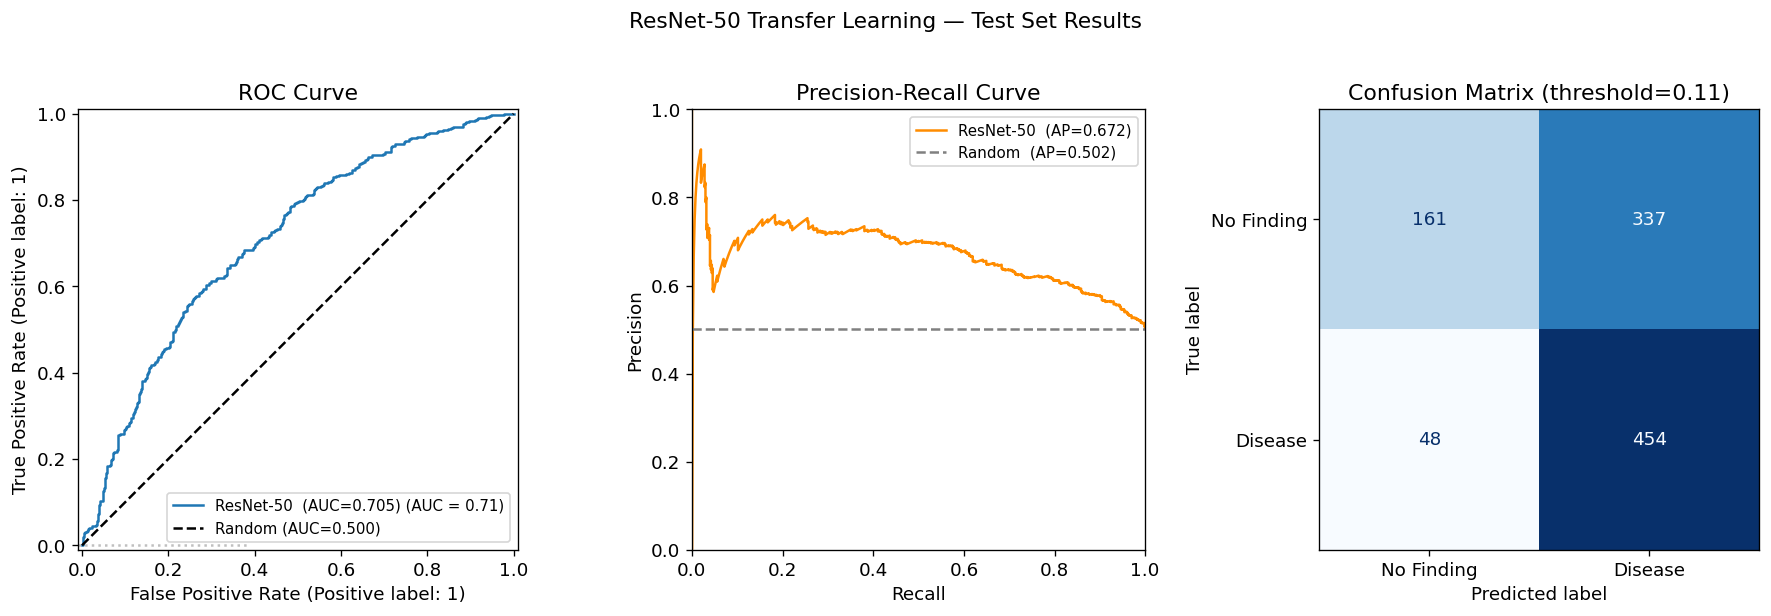

In [4]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ROC curve
ax1 = fig.add_subplot(gs[0])
RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax1,
                                  name=f"ResNet-50  (AUC={auc:.3f})")
ax1.plot([0,1],[0,1],"k--",label="Random (AUC=0.500)")
ax1.axhline(y=0, xmin=0, xmax=0.389, color="gray", linestyle=":", alpha=0.5)
ax1.set_title("ROC Curve")
ax1.legend(fontsize=9)

# Precision-Recall curve
ax2 = fig.add_subplot(gs[1])
pc, rc, _ = precision_recall_curve(all_labels, all_probs)
ap        = average_precision_score(all_labels, all_probs)
prev      = all_labels.mean()
ax2.plot(rc, pc, color="darkorange", label=f"ResNet-50  (AP={ap:.3f})")
ax2.axhline(y=prev, color="gray", linestyle="--", label=f"Random  (AP={prev:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# Confusion matrix
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Finding", "Disease"]).plot(
    ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")

plt.suptitle("ResNet-50 Transfer Learning — Test Set Results", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Key Findings

**Transfer learning outperforms the baseline.** ResNet-50 achieves AUC 0.705 vs the baseline CNN's 0.611 — a meaningful improvement despite training on the same small dataset. ImageNet pretraining gives the model a head start on low-level visual features (edges, textures, shapes) that are useful even for medical images.

**The model behaves as a sensitive screener.** With a tuned threshold of 0.11, the model achieves recall of ~90% — it correctly flags 9 out of 10 disease cases. This comes at the cost of precision (~57%): roughly 4 in 10 flagged images are false alarms. For a screening tool whose goal is to reduce the number of disease cases that go undetected, this trade-off is appropriate.

**The model is not well-calibrated.** The optimal threshold of 0.11 (not 0.5) reveals that the model outputs systematically low probabilities. This means raw probabilities cannot be used as clinical confidence scores — a calibration step would be needed before deployment.

**Data is the bottleneck.** Both models show training loss far below validation loss — classic overfitting on a small dataset. With 1,000 training images and 23.5 million parameters, ResNet-50 has far more capacity than data to fill it. The full 112,120-image dataset would substantially change these results.

---
## 6. Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| Trained on 1,000 images per split (~1% of dataset) | Overfitting; results not generalisable | Train on full dataset with GPU |
| NLP-extracted labels (~90% accurate) | Label noise degrades true signal | Expert re-labeling or label-smoothing |
| Binary label only | Cannot distinguish disease type | Multi-label classification |
| Not calibrated | Probabilities unreliable for clinical scoring | Platt scaling or isotonic regression |
| Single architecture tested | Unknown if ResNet-50 is optimal | Compare DenseNet-121, EfficientNet |
| No external validation | Results may not generalize to other hospitals | Test on CheXpert or MIMIC-CXR |

---
## 7. What's Next

The most impactful immediate step is scaling to the full dataset:

1. **Full dataset training** — 112,120 images with a GPU (Colab T4 or A100). Expected to substantially reduce overfitting and improve AUC.
2. **Model calibration** — Apply Platt scaling to make probabilities interpretable.
3. **DenseNet-121** — The canonical architecture for this dataset in the literature. Compare against ResNet-50.
4. **Class-weighted loss** — Explicitly penalize false negatives more than false positives during training.
5. **Grad-CAM visualization** — Highlight which regions of the X-ray drove the model's prediction — critical for clinical trust.

---
## 8. Live Prediction Demo

This cell loads the trained ResNet-50 and runs inference on a single X-ray image.
Point `IMAGE_PATH` at any `.png` chest X-ray to get a prediction.

> Requires: `models/resnet50_phase5.pt` (saved at end of notebook 05)

Using image: /Volumes/T7 Shield/x-ray-datasets/archive/images_006/images/00011723_001.png


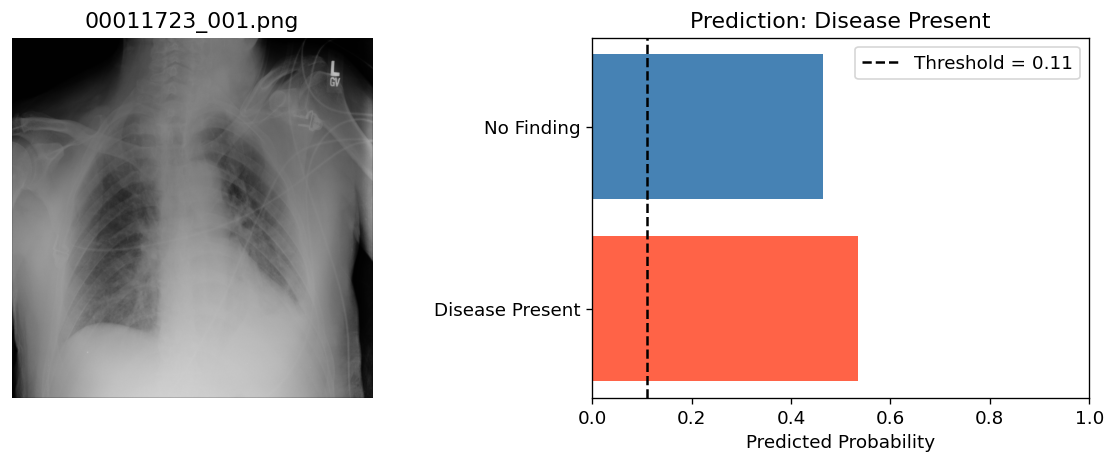

Image:       00011723_001.png
Probability: 0.535
Threshold:   0.11
Prediction:  Disease Present


In [5]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

# Auto-find an available image — change IMAGE_PATH to any specific file if preferred
SEARCH_DIRS = [
    Path("/Volumes/T7 Shield/x-ray-datasets/archive/images_006/images"),
    Path("/Volumes/T7 Shield/x-ray-datasets/nb_images"),
    Path("../../data/images"),
]

IMAGE_PATH = None
for d in SEARCH_DIRS:
    found = list(d.glob("*.png"))
    if found:
        IMAGE_PATH = found[0]
        break

if IMAGE_PATH is None:
    raise FileNotFoundError("No .png images found. Set IMAGE_PATH manually to a local X-ray file.")

print(f"Using image: {IMAGE_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODELS_DIR / "resnet50_phase5.pt", map_location=device))
model = model.to(device)
model.eval()

# Preprocess image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img    = Image.open(IMAGE_PATH).convert("RGB")
tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    prob = torch.sigmoid(model(tensor)).item()

prediction = "Disease Present" if prob >= best_threshold else "No Finding"

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img, cmap="gray")
axes[0].set_title(IMAGE_PATH.name)
axes[0].axis("off")

axes[1].barh(["Disease Present", "No Finding"],
             [prob, 1 - prob],
             color=["tomato", "steelblue"])
axes[1].axvline(x=best_threshold, color="black", linestyle="--",
                label=f"Threshold = {best_threshold:.2f}")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Predicted Probability")
axes[1].set_title(f"Prediction: {prediction}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Image:       {IMAGE_PATH.name}")
print(f"Probability: {prob:.3f}")
print(f"Threshold:   {best_threshold:.2f}")
print(f"Prediction:  {prediction}")

---

## Project Repository

**GitHub:** https://github.com/portablerug/x-ray-classification

| Notebook | Phase |
|----------|-------|
| `01_data_loading.ipynb` | BigQuery connection and metadata pull |
| `02_label_engineering.ipynb` | Binary labels and patient-level splits |
| `03_image_pipeline.ipynb` | Image transforms and DataLoaders |
| `04_baseline_model.ipynb` | Baseline CNN training and evaluation |
| `05_transfer_learning.ipynb` | ResNet-50 two-phase transfer learning |
| `06_evaluation.ipynb` | Statistical evaluation and clinical interpretation |
| `07_report.ipynb` | This report |

---
*PSTAT 134 — Spring 2026 — UC Santa Barbara*

git add README.md notebooks/05_transfer_learning.ipynb notebooks/06_evaluation.ipynb notebooks/07_report.ipynb